In [2]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
species_colors = {
    'human': '#1f77b4',  # blue
    'mouse': '#ff7f0e',  # orange
}

human_fn = "/home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/alphagenome_metadata_homo_sapiens.csv"
human_data = pd.read_csv(human_fn, index_col=0)
human_data['species'] = 'human'
display(human_data)

mouse_fn = "/home/elek/sds/sd17d003/Anamaria/alphagenome_genomicsxai/alphagenome_metadata_mus_musculus.csv"
mouse_data = pd.read_csv(mouse_fn,index_col=0)
mouse_data['species'] = 'mouse'
display(mouse_data)

,name,strand,Assay title,ontology_curie,biosample_name,biosample_type,biosample_life_stage,data_source,endedness,genetically_modified,nonzero_mean,output_type,gtex_tissue,histone_mark,transcription_factor,species
0,CL:0000084 ATAC-seq,.,ATAC-seq,CL:0000084,T-cell,primary_cell,adult,encode,paired,False,0.739741,OutputType.ATAC,NaN,NaN,NaN,human
1,CL:0000100 ATAC-seq,.,ATAC-seq,CL:0000100,motor neuron,in_vitro_differentiated_cells,adult,encode,paired,False,0.273136,OutputType.ATAC,NaN,NaN,NaN,human
2,CL:0000236 ATAC-seq,.,ATAC-seq,CL:0000236,B cell,primary_cell,adult,encode,paired,False,4.700081,OutputType.ATAC,NaN,NaN,NaN,human
3,CL:0000623 ATAC-seq,.,ATAC-seq,CL:0000623,natural killer cell,primary_cell,adult,encode,paired,False,0.938715,OutputType.ATAC,NaN,NaN,NaN,human
4,CL:0000624 ATAC-seq,.,ATAC-seq,CL:0000624,"CD4-positive, alpha-beta T cell",primary_cell,adult,encode,paired,False,4.365206,OutputType.ATAC,NaN,NaN,NaN,human
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7,ENCSR182QNJ,-,PRO-cap,EFO:0001099,Caco-2,cell_line,NaN,encode,NaN,False,14.002803,OutputType.PROCAP,NaN,NaN,NaN,human
8,ENCSR740IPL,-,PRO-cap,EFO:0002067,K562,cell_line,NaN,encode,NaN,False,15.765458,OutputType.PROCAP,NaN,NaN,NaN,human
9,ENCSR797DEF,-,PRO-cap,EFO:0002819,Calu3,cell_line,NaN,encode,NaN,False,12.281321,OutputType.PROCAP,NaN,NaN,NaN,human
10,ENCSR801ECP,-,PRO-cap,CL:0002618,endothelial cell of umbilical vein,primary_cell,NaN,encode,NaN,False,13.973692,OutputType.PROCAP,NaN,NaN,NaN,human


,name,strand,Assay title,ontology_curie,biosample_name,biosample_type,biosample_life_stage,data_source,endedness,genetically_modified,nonzero_mean,output_type,gtex_tissue,histone_mark,transcription_factor,species
0,CL:0000553 ATAC-seq,.,ATAC-seq,CL:0000553,megakaryocyte progenitor cell,primary_cell,adult,encode,single,False,2.005908,OutputType.ATAC,NaN,NaN,NaN,mouse
1,CL:0000557 ATAC-seq,.,ATAC-seq,CL:0000557,granulocyte monocyte progenitor cell,primary_cell,adult,encode,single,False,1.801482,OutputType.ATAC,NaN,NaN,NaN,mouse
2,CL:0000792 ATAC-seq,.,ATAC-seq,CL:0000792,"CD4-positive, CD25-positive, alpha-beta regula...",primary_cell,adult,encode,paired,False,3.149848,OutputType.ATAC,NaN,NaN,NaN,mouse
3,EFO:0005481 ATAC-seq,.,ATAC-seq,EFO:0005481,Patski,cell_line,unknown,encode,paired,False,2.537327,OutputType.ATAC,NaN,NaN,NaN,mouse
4,NTR:0004148 ATAC-seq,.,ATAC-seq,NTR:0004148,"activated CD4-positive, CD25-positive, alpha-b...",primary_cell,adult,encode,paired,False,5.302505,OutputType.ATAC,NaN,NaN,NaN,mouse
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3,4dn:4DNFIC21MG3U,.,in situ Hi-C,EFO:0004038,mouse embryonic stem cell,cell_line,NaN,4dnucleome,NaN,NaN,NaN,OutputType.CONTACT_MAPS,NaN,NaN,NaN,mouse
4,4dn:4DNFIHBTUDO9,.,in situ Hi-C,CL:0000207,olfactory receptor cell,primary_cell,NaN,4dnucleome,NaN,NaN,NaN,OutputType.CONTACT_MAPS,NaN,NaN,NaN,mouse
5,4dn:4DNFIKK3QG34,.,in situ Hi-C,EFO:0005484,46C,cell_line,NaN,4dnucleome,NaN,NaN,NaN,OutputType.CONTACT_MAPS,NaN,NaN,NaN,mouse
6,4dn:4DNFIMV54HXI,.,in situ Hi-C,CL:0000207,olfactory receptor cell,primary_cell,NaN,4dnucleome,NaN,NaN,NaN,OutputType.CONTACT_MAPS,NaN,NaN,NaN,mouse


In [13]:
display(human_data['output_type'].value_counts())
display(mouse_data['output_type'].value_counts())

output_type
OutputType.CHIP_TF              1617
OutputType.CHIP_HISTONE         1116
OutputType.SPLICE_SITE_USAGE     734
OutputType.RNA_SEQ               667
OutputType.CAGE                  546
OutputType.SPLICE_JUNCTIONS      367
OutputType.DNASE                 305
OutputType.ATAC                  167
OutputType.CONTACT_MAPS           28
OutputType.PROCAP                 12
OutputType.SPLICE_SITES            4
Name: count, dtype: int64

output_type
OutputType.CAGE                 188
OutputType.CHIP_HISTONE         183
OutputType.SPLICE_SITE_USAGE    180
OutputType.RNA_SEQ              173
OutputType.CHIP_TF              127
OutputType.SPLICE_JUNCTIONS      90
OutputType.DNASE                 67
OutputType.ATAC                  18
OutputType.CONTACT_MAPS           8
OutputType.SPLICE_SITES           4
Name: count, dtype: int64

In [37]:
human_splice_data = human_data[human_data['output_type'].isin(['OutputType.SPLICE_SITE_USAGE'])]
mouse_splice_data = mouse_data[mouse_data['output_type'].isin(['OutputType.SPLICE_SITE_USAGE'])]
splice_data = pd.concat([human_splice_data, mouse_splice_data])
# prevent double counting
splice_data = splice_data[splice_data['strand'] == '+']
splice_data

,name,strand,Assay title,ontology_curie,biosample_name,biosample_type,biosample_life_stage,data_source,endedness,genetically_modified,nonzero_mean,output_type,gtex_tissue,histone_mark,transcription_factor,species
0,usage_CL:0000047 polyA plus RNA-seq,+,polyA plus RNA-seq,CL:0000047,neuronal stem cell,in_vitro_differentiated_cells,embryonic,encode,NaN,NaN,NaN,OutputType.SPLICE_SITE_USAGE,NaN,NaN,NaN,human
1,usage_CL:0000062 total RNA-seq,+,total RNA-seq,CL:0000062,osteoblast,primary_cell,adult,encode,NaN,NaN,NaN,OutputType.SPLICE_SITE_USAGE,NaN,NaN,NaN,human
2,usage_CL:0000084 polyA plus RNA-seq,+,polyA plus RNA-seq,CL:0000084,T-cell,primary_cell,adult,encode,NaN,NaN,NaN,OutputType.SPLICE_SITE_USAGE,NaN,NaN,NaN,human
3,usage_CL:0000084 total RNA-seq,+,total RNA-seq,CL:0000084,T-cell,primary_cell,adult,encode,NaN,NaN,NaN,OutputType.SPLICE_SITE_USAGE,NaN,NaN,NaN,human
4,usage_CL:0000100 total RNA-seq,+,total RNA-seq,CL:0000100,motor neuron,in_vitro_differentiated_cells,adult,encode,NaN,NaN,NaN,OutputType.SPLICE_SITE_USAGE,NaN,NaN,NaN,human
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,usage_UBERON:0002370 polyA plus RNA-seq,+,polyA plus RNA-seq,UBERON:0002370,thymus,tissue,adult,encode,NaN,NaN,NaN,OutputType.SPLICE_SITE_USAGE,NaN,NaN,NaN,mouse
86,usage_UBERON:0002371 polyA plus RNA-seq,+,polyA plus RNA-seq,UBERON:0002371,bone marrow,tissue,adult,encode,NaN,NaN,NaN,OutputType.SPLICE_SITE_USAGE,NaN,NaN,NaN,mouse
87,usage_UBERON:0003428 polyA plus RNA-seq,+,polyA plus RNA-seq,UBERON:0003428,gonadal fat pad,tissue,adult,encode,NaN,NaN,NaN,OutputType.SPLICE_SITE_USAGE,NaN,NaN,NaN,mouse
88,usage_UBERON:0005343 polyA plus RNA-seq,+,polyA plus RNA-seq,UBERON:0005343,cortical plate,tissue,adult,encode,NaN,NaN,NaN,OutputType.SPLICE_SITE_USAGE,NaN,NaN,NaN,mouse


/tmp/ipykernel_3179290/2224295538.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  splice_data['biosample_count'] = splice_data.groupby(['biosample_type', 'species'])['biosample_type'].transform('count')


Text(0, 0.5, 'Biosample Type')

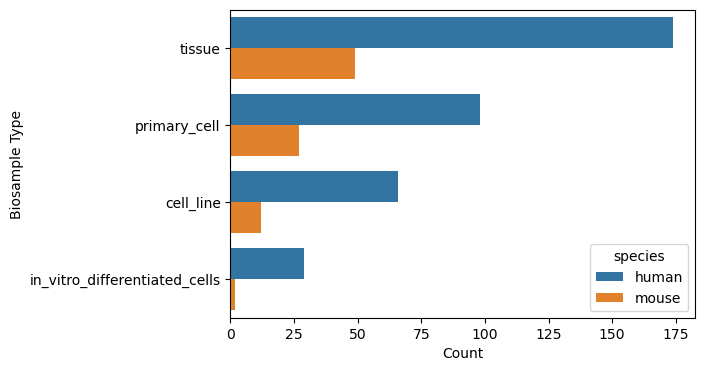

In [150]:
# Sort per count of biosample_type
splice_data['biosample_count'] = splice_data.groupby(['biosample_type', 'species'])['biosample_type'].transform('count')
splice_data = splice_data.sort_values('biosample_count', ascending=True)
biosample_type_categories = splice_data['biosample_type'].unique()
biosample_type_categories = biosample_type_categories[::-1]
splice_data['biosample_type'] = pd.Categorical(splice_data['biosample_type'], categories=biosample_type_categories, ordered=True)
splice_data['species'] = pd.Categorical(splice_data['species'], categories=species_colors.keys(), ordered=True)

plt.figure(figsize=(6, 4))
sns.countplot(data=splice_data, y='biosample_type', hue='species', palette=species_colors, order=biosample_type_categories, orient='h')
plt.xlabel('Count')
plt.ylabel('Biosample Type')

In [157]:
# rename biosample_type that has cell into cell line
splice_data['biosample_type'] = splice_data['biosample_type'].apply(lambda x: 'cell line' if 'cell' in x.lower() else x)
splice_data['biosample_count'] = splice_data.groupby(['biosample_type', 'species'])['biosample_type'].transform('count')
df = splice_data[['species', 'biosample_type', 'biosample_count']].drop_duplicates()
pivot_df = df.pivot(index='species', columns='biosample_type', values='biosample_count').fillna(0)
pivot_df

/tmp/ipykernel_3179290/2124218180.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  splice_data['biosample_count'] = splice_data.groupby(['biosample_type', 'species'])['biosample_type'].transform('count')


biosample_type,cell line,tissue
species,,
human,193,174
mouse,41,49


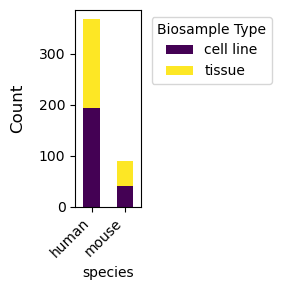

In [168]:
pivot_df = splice_data[['species', 'biosample_type', 'biosample_count']].drop_duplicates().pivot(index='species', columns='biosample_type', values='biosample_count').fillna(0)
pivot_df['Total'] = pivot_df.sum(axis=1)
pivot_df = pivot_df.sort_values(by='Total', ascending=False).drop(columns='Total')

fig, ax = plt.subplots(figsize=(3, 3))
pivot_df.plot(kind='bar', stacked=True, ax=ax, cmap='viridis')
ax.set_ylabel('Count', fontsize=12, labelpad=10)
ax.legend(title='Biosample Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

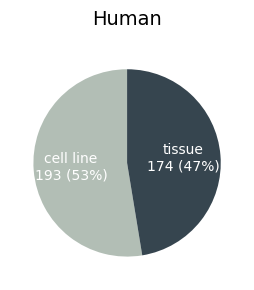

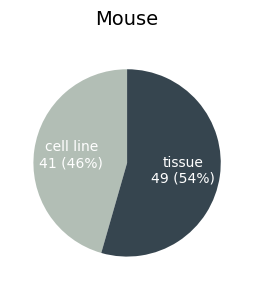

In [ ]:
for species in pivot_df.index:
    species_data = pivot_df.loc[species]
    species_data = species_data[species_data > 0]
    
    plt.figure(figsize=(3, 3))
    
    def make_autopct(values, labels):
        def my_autopct(pct):
            total = sum(values)
            val = int(round(pct * total / 100.0))
            try:
                idx = list(values).index(val)
                label = labels[idx]
            except ValueError:
                label = ""
            return f"{label}\n{val} ({pct:.0f}%)"
        return my_autopct

    # Plot the pie chart
    species_data.plot(
        kind='pie', 
        autopct=make_autopct(species_data.values, species_data.index),
        startangle=90, 
        colors=['#B2BEB5', "#36454F"],
        labels=None,
        textprops={'fontsize': 10, 'color': 'white'}
    )
    
    plt.title(f'{species.capitalize()}', fontsize=14, pad=15)
    plt.ylabel('')
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_3179290/148042299.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  splice_tissue_data['biosample_life_stage_count'] = splice_tissue_data.groupby(['biosample_life_stage', 'species'])['biosample_life_stage'].transform('count')
/tmp/ipykernel_3179290/148042299.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  splice_tissue_data['biosample_life_stage_count'] = splice_tissue_data.groupby(['biosample_life_stage', 'species'])['biosample_life_stage'].transform('count')


Text(0, 0.5, 'Biosample Life Stage')

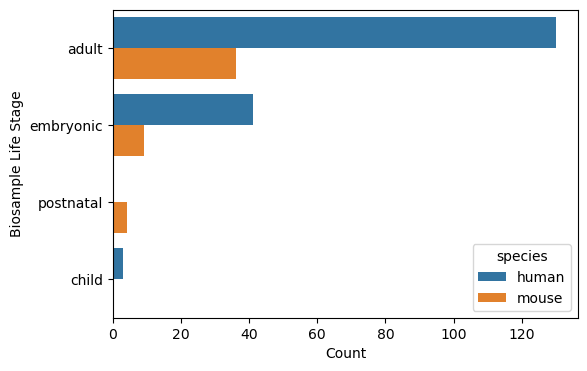

In [179]:
splice_tissue_data = splice_data[splice_data['biosample_type'] == 'tissue']
splice_tissue_data['biosample_life_stage_count'] = splice_tissue_data.groupby(['biosample_life_stage', 'species'])['biosample_life_stage'].transform('count')
splice_tissue_data = splice_tissue_data.sort_values('biosample_life_stage_count', ascending=True)
biosample_life_stage_categories = splice_tissue_data['biosample_life_stage'].unique()
biosample_life_stage_categories = biosample_life_stage_categories[::-1]
splice_tissue_data['biosample_life_stage'] = pd.Categorical(splice_tissue_data['biosample_life_stage'], categories=biosample_life_stage_categories, ordered=True)


plt.figure(figsize=(6, 4))
sns.countplot(data=splice_tissue_data, y='biosample_life_stage', hue='species', palette=species_colors, order=biosample_life_stage_categories, orient='h')
plt.xlabel('Count')
plt.ylabel('Biosample Life Stage')


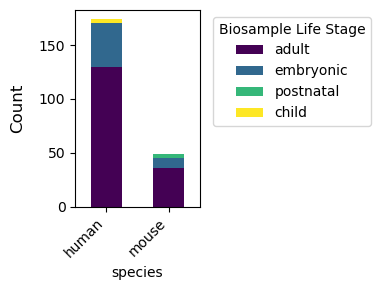

In [ ]:
pivot_df = splice_tissue_data[['species', 'biosample_life_stage', 'biosample_life_stage_count']].drop_duplicates().pivot(index='species', columns='biosample_life_stage', values='biosample_life_stage_count').fillna(0)
pivot_df['Total'] = pivot_df.sum(axis=1)
pivot_df = pivot_df.sort_values(by='Total', ascending=False).drop(columns='Total')

fig, ax = plt.subplots(figsize=(4, 3))
pivot_df.plot(kind='bar', stacked=True, ax=ax, cmap='viridis')
ax.set_ylabel('Count', fontsize=12, labelpad=10)
ax.legend(title='Biosample Life Stage', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

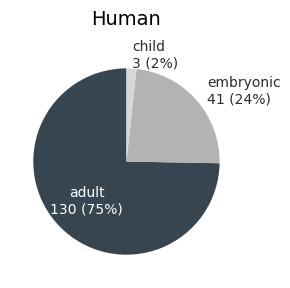

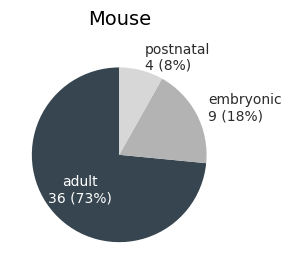

In [192]:
for species in pivot_df.index:
    species_data = pivot_df.loc[species]
    species_data = species_data[species_data > 0]
    
    if species_data.empty:
        continue

    # 1. Create custom combined text (Label + Value + %) for every slice
    total = species_data.sum()
    formatted_labels = []
    for label, val in species_data.items():
        pct = (val / total) * 100
        formatted_labels.append(f"{label}\n{np.int64(val)} ({pct:.0f}%)")

    # 2. Split labels based on the 1/3 (33.3%) threshold
    inside_labels = []
    outside_labels = []
    
    for val, full_text in zip(species_data.values, formatted_labels):
        fraction = val / total
        if fraction >= (1/3):
            inside_labels.append(full_text)  # Show inside
            outside_labels.append("")        # Keep outside clean
        else:
            inside_labels.append("")        # Keep inside clean
            outside_labels.append(full_text) # Show outside

    # 3. Custom generator for inside text elements
    def conditional_autopct(inside_list):
        # Iterates through our pre-calculated inside labels
        iterator = iter(inside_list)
        return lambda pct: next(iterator)

    # Figure size expanded to (5, 5) to safely fit outside text padding
    fig, ax = plt.subplots(figsize=(3, 3))
    
    # 4. Plot the pie chart
    wedges, texts, autotexts = ax.pie(
        species_data,
        labels=outside_labels,                            # Handles small slice labels outside
        autopct=conditional_autopct(inside_labels),       # Handles large slice labels inside
        startangle=90,
        colors=["#36454F", "#B2B3B2", "#D7D7D7", "#F0F0F0"][:len(species_data)],
        textprops={'fontsize': 10, 'color': 'black'},     # Default color for outside text
        pctdistance=0.6,                                  # Distance from center for inside labels
        labeldistance=1.15                                # Distance from center for outside labels
    )
    
    # 5. Fine-tune text colors based on placement
    # Make inside text bold and white (since the first color is #36454F dark charcoal)
    for autotext in autotexts:
        if autotext.get_text():
            autotext.set_color('white')
            
    # Optional: Make outside text distinct or slightly smaller if needed
    for text in texts:
        if text.get_text():
            text.set_color('#2b2b2b') # Dark grey for readable outside text
            text.set_weight('medium')

    ax.set_title(f'{species.capitalize()}', fontsize=14, pad=15)
    plt.tight_layout()
    plt.show()

In [198]:
splice_tissue_data = splice_data[(splice_data['biosample_type'] == 'tissue') & (splice_data['biosample_life_stage'] == 'adult') ]

# summarize biosample_name by grepping for broad categorise:
# brain, heart, liver, lung, kidney, muscle, blood, skin, colon, intestine, pancreas, spleen, testis, ovary
def categorize_biosample_name(name):
    name = name.lower()
    if 'brain' in name or 'cerebral' in name or 'cerebellum' in name or 'cerebellar' in name or 'hippocampus' in name or 'cortex' in name or 'nucleus' in name or 'medulla' in name or 'thalamus' in name or 'hypothalamus' in name or 'putamen' in name or 'olfactory' in name or 'amygdala' in name or 'striatum' in name or 'substantia' in name or 'pituitary' in name or 'horn' in name or 'ganglion' in name or 'choroid' in name or 'ependymal' in name or 'meninges' in name:
        return 'brain'
    elif 'nerve' in name or 'neuron' in name or 'glia' in name or 'astrocyte' in name or 'oligodendrocyte' in name or 'microglia' in name  or 'spinal' in name:
        return 'nervous'
    elif 'heart' in name or 'cardiac' in name or 'ventricle' in name or 'atrium' in name:
        return 'heart'
    elif 'liver' in name:
        return 'liver'
    elif 'lung' in name:
        return 'lung'
    elif 'bone' in name or 'cortical' in name:
        return 'bone'
    elif 'kidney' in name or 'adrenal' in name or 'renal' in name:
        return 'kidney'
    elif 'muscle' in name or 'gastrocnemius' in name or 'quadriceps' in name or 'diaphragm' in name or 'myocardium' in name:
        return 'muscle'
    elif 'blood' in name or 'lymphoblast' in name or 'leukocyte' in name or 'lymphocyte' in name or 'erythrocyte' in name or 'monocyte' in name or 'granulocyte' in name or 'macrophage' in name or 'neutrophil' in name or 'eosinophil' in name or 'basophil' in name:
        return 'blood'
    elif 'aorta' in name or 'artery' in name or 'vein' in name or 'vena' in name or 'venous' in name or 'vascular' in name:
        return 'blood vessel'
    elif 'skin' in name or 'subcutaneous' in name or 'dermis' in name or 'epidermis' in name or 'fibroblast' in name or 'keratinocyte' in name or 'melanocyte' in name:
        return 'skin'
    elif 'thyroid' in name or 'thymus' in name or 'parathyroid' in name:
        return 'thyroid'
    elif 'lingual' in name or 'esophagus' in name:
        return 'digestive'
    elif 'stomach' in name or 'omental fat pad' in name or 'gastroesophageal' in name:
        return 'stomach'
    elif 'adipose' in name or 'fat' in name:
        return 'adipose'
    elif 'intestine' in name or 'colon' in name or 'rectum' in name or 'duodenum' in name or 'jejunum' in name or 'ileum' in name or "patch" in name:
        return 'intestine'
    elif 'pancreas' in name:
        return 'pancreas'
    elif 'spleen' in name:
        return 'spleen'
    elif 'bladder' in name or 'urinary' in name or 'ureter' in name or 'urethra' in name:
        return 'urinary'
    elif 'testis' in name or 'seminal' in name:
        return 'testis'
    elif 'prostate' in name:
        return 'prostate'
    elif 'uterus' in name or 'placenta' in name or 'endocervix' in name or 'ectocervix' in name or 'vagina' in name:
        return 'uterus'
    elif 'ovary' in name or 'fallopian' in name:
        return 'ovary'
    elif 'breast' in name or 'mammary' in name:
        return 'breast'
    else:
        return 'other'
    
splice_tissue_data['biosample_category'] = splice_tissue_data['biosample_name'].apply(categorize_biosample_name)
splice_tissue_data['biosample_category_counts'] = splice_tissue_data['biosample_category'].map(splice_tissue_data['biosample_category'].value_counts())
splice_tissue_data = splice_tissue_data.sort_values('biosample_category_counts', ascending=False)
sample_categories = splice_tissue_data['biosample_category'].unique()
sample_categories = sample_categories[::-1]
splice_tissue_data['biosample_category'] = pd.Categorical(splice_tissue_data['biosample_category'], categories=sample_categories)
splice_tissue_data['species'] = pd.Categorical(splice_tissue_data['species'], categories=['human', 'mouse'])


/tmp/ipykernel_3179290/3951665564.py:58: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  splice_tissue_data['biosample_category'] = splice_tissue_data['biosample_name'].apply(categorize_biosample_name)
/tmp/ipykernel_3179290/3951665564.py:59: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  splice_tissue_data['biosample_category_counts'] = splice_tissue_data['biosample_category'].map(splice_tissue_data['biosample_category'].value_counts())


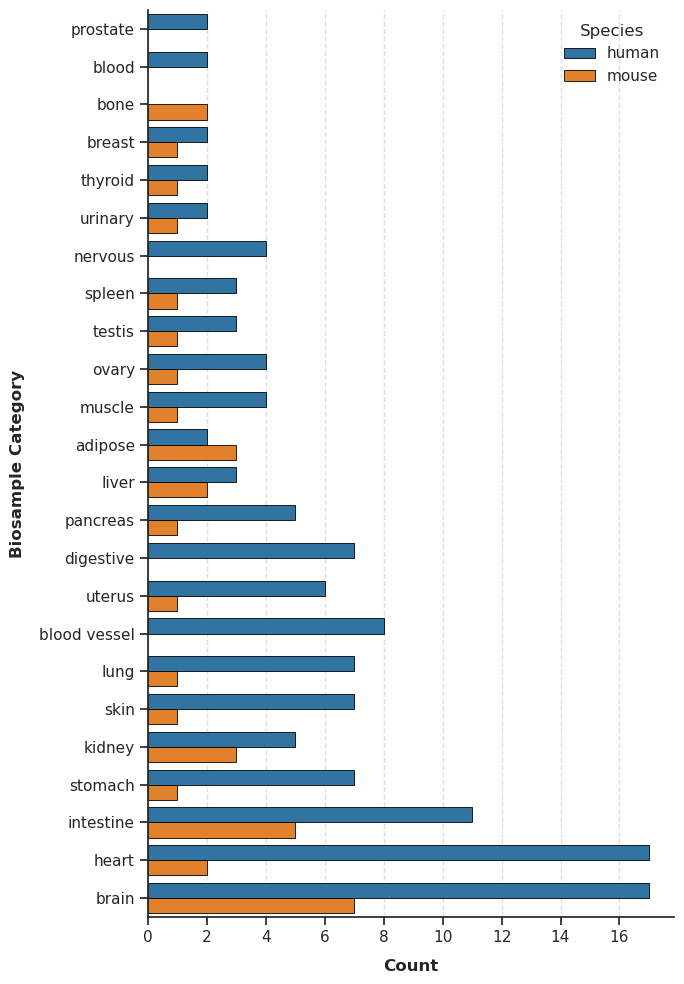

In [205]:
sns.set_theme(style="ticks")
plt.figure(figsize=(7, 10))

ax = sns.countplot(
    data=splice_tissue_data, 
    y='biosample_category', 
    hue='species', 
    palette=species_colors,
    orient='h',
    edgecolor='black',  # Adds crisp definition to the bars
    linewidth=0.6
)

ax.xaxis.grid(True, linestyle='--', alpha=0.6, color='#CCCCCC')
ax.set_axisbelow(True) # Ensures grid lines sit safely behind the bars

plt.xlabel('Count', fontsize=12, labelpad=10, weight='semibold')
plt.ylabel('Biosample Category', fontsize=12, labelpad=10, weight='semibold')

sns.move_legend(
    ax, 
    loc="upper right",
    ncol=1,                     # Arranges species side-by-side
    title="Species",
    frameon=False               # Removes the box around the legend
)

sns.despine(ax=ax, top=True, right=True)

plt.tight_layout()
plt.show()

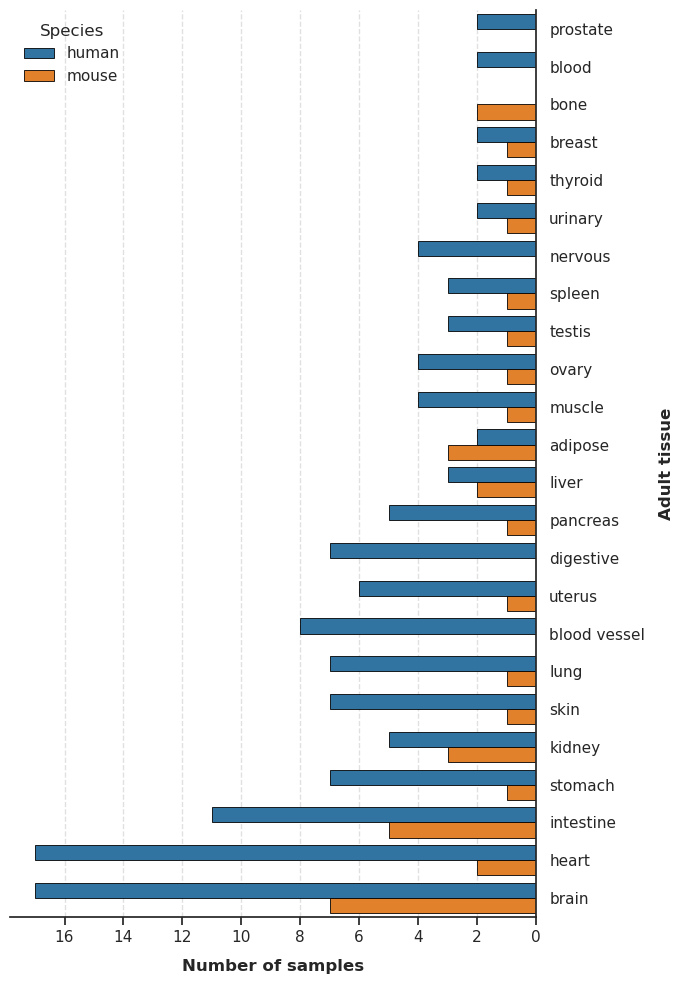

In [206]:
sns.set_theme(style="ticks")
plt.figure(figsize=(7, 10))

ax = sns.countplot(
    data=splice_tissue_data, 
    y='biosample_category', 
    hue='species', 
    palette=species_colors,
    orient='h',
    edgecolor='black',  
    linewidth=0.6
)

ax.xaxis.grid(True, linestyle='--', alpha=0.6, color='#CCCCCC')
ax.set_axisbelow(True) 

# --- FLIP PLOT HORIZONTALLY ---
ax.invert_xaxis()          # Forces the X-axis to go from Max (left) to 0 (right)
ax.yaxis.tick_right()      # Moves the category text labels to the right side
ax.yaxis.set_label_position("right") # Moves the "Biosample Category" title to the right

plt.xlabel('Number of samples', fontsize=12, labelpad=10, weight='semibold')
plt.ylabel('Adult tissue', fontsize=12, labelpad=10, weight='semibold')

# Adjusted legend location to "upper left" so it doesn't block the inverted bars
sns.move_legend(
    ax, 
    loc="upper left",
    ncol=1,                     
    title="Species",
    frameon=False               
)

# Adjust despine to remove the LEFT axis line instead of the right one
sns.despine(ax=ax, top=True, left=True, right=False)

plt.tight_layout()
plt.show()